# CT First POC

I built this notebook as a clean first pass for CT image analysis.


## Notebook plan

- inspect the dataset properly
- build a classical texture baseline
- train a small CNN baseline
- compare the results
- export embeddings and metadata for later downstream analysis


## Why this dataset

I use the **CT-Scan images** dataset from Kaggle.

I picked it because:

- it is small enough to run on a normal machine
- the binary class setup keeps the story clean
- it lets me focus on understanding the pipeline instead of hiding behind size
- it is a good dataset for learning the mechanics of CT image analysis, baseline modelling, and embedding extraction


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.measure import shannon_entropy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)


Running on: cpu


In [3]:
DATA_DIR = Path(r"C:\Users\nosai\Downloads\CT_first_poc_repo\data\ct-scan Images")
OUTPUT_DIR = Path(r"C:\Users\nosai\Downloads\CT_first_poc_repo\data\ct-scan Images\outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    print("Dataset folder not found.")
    print("Expected path:")
    print(DATA_DIR.resolve())
else:
    print("Dataset folder found:", DATA_DIR.resolve())


Dataset folder found: C:\Users\nosai\Downloads\CT_first_poc_repo\data\ct-scan Images


In [4]:
records = []

if DATA_DIR.exists():
    for class_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
        class_name = class_dir.name
        for img_path in class_dir.glob("**/*"):
            if img_path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
                records.append({"path": str(img_path), "label": class_name})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 364


,path,label
0,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer
1,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer
2,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer
3,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer
4,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer


In [5]:
if len(df) > 0:
    display(df["label"].value_counts().to_frame("count"))


,count
label,
Cancer,238
Non-Cancer,126


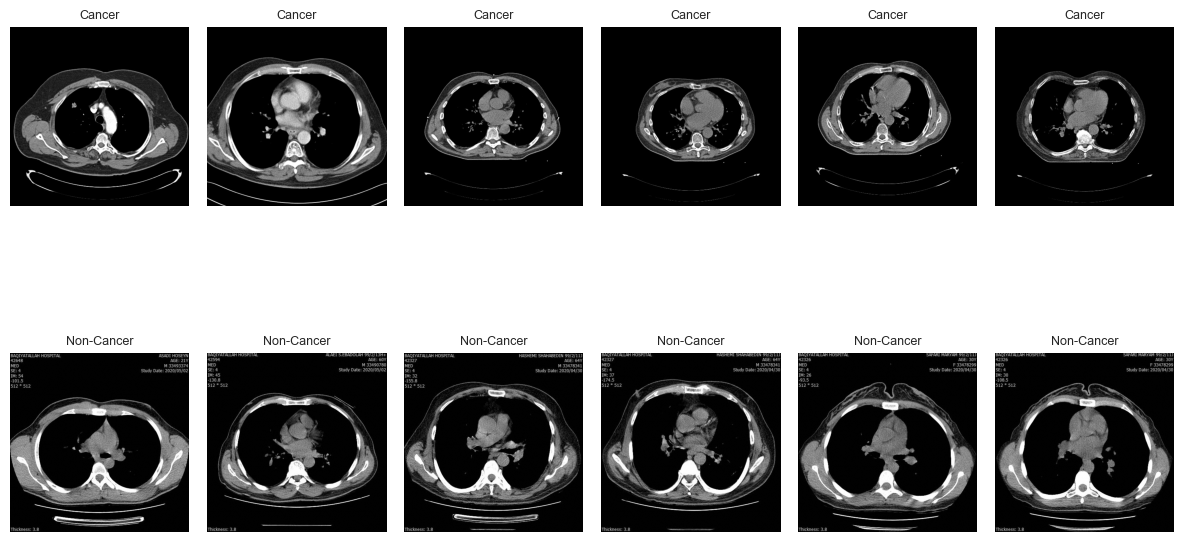

In [6]:
if len(df) > 0:
    sample_df = df.groupby("label", group_keys=False).head(6)
    classes = list(sample_df["label"].unique())
    fig, axes = plt.subplots(len(classes), 6, figsize=(12, 4 * len(classes)))
    axes = np.array(axes).reshape(len(classes), 6)

    for row_idx, (label, group) in enumerate(sample_df.groupby("label")):
        for col_idx, (_, row) in enumerate(group.iterrows()):
            img = Image.open(row["path"]).convert("L")
            axes[row_idx, col_idx].imshow(img, cmap="gray")
            axes[row_idx, col_idx].set_title(label, fontsize=9)
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
    plt.show()


## Classical baseline

I start with handcrafted grayscale features for one simple reason.

If a small classical model already performs well, that tells me the data carry useful texture signal. If the CNN later improves, I know what it actually beat.

That makes the story much cleaner.


In [7]:
def extract_ct_features(image_path, lbp_points=8, lbp_radius=1):
    # I force grayscale because that is the signal I actually want to reason about for CT here.
    img = Image.open(image_path).convert("L")
    arr = np.array(img).astype(np.float32) / 255.0
    gray_uint8 = (arr * 255).astype(np.uint8)

    # These are the simplest intensity summaries.
    mean_intensity = arr.mean()
    std_intensity = arr.std()

    # Entropy gives me a rough sense of local visual complexity.
    entropy = shannon_entropy(gray_uint8)

    # LBP gives me a compact texture description.
    lbp = local_binary_pattern(gray_uint8, P=lbp_points, R=lbp_radius, method="uniform")
    n_bins = lbp_points + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    # GLCM features are cheap, classical, and still useful for texture-heavy medical images.
    glcm = graycomatrix(
        gray_uint8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast")[0, 0]
    dissimilarity = graycoprops(glcm, "dissimilarity")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy = graycoprops(glcm, "energy")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]
    asm = graycoprops(glcm, "ASM")[0, 0]

    features = np.concatenate([
        np.array([
            mean_intensity,
            std_intensity,
            entropy,
            contrast,
            dissimilarity,
            homogeneity,
            energy,
            correlation,
            asm
        ]),
        lbp_hist
    ])

    return features


In [8]:
if len(df) > 0:
    X_hand = []
    for p in tqdm(df["path"], desc="Extracting CT handcrafted features"):
        X_hand.append(extract_ct_features(p))
    X_hand = np.vstack(X_hand)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df["label"])

    print("Handcrafted feature matrix shape:", X_hand.shape)
    print("Classes:", list(label_encoder.classes_))


Extracting CT handcrafted features:   0%|          | 0/364 [00:00<?, ?it/s]

Handcrafted feature matrix shape: (364, 19)
Classes: ['Cancer', 'Non-Cancer']


In [9]:
if len(df) > 0:
    X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
        X_hand, y, df, test_size=0.2, random_state=SEED, stratify=y
    )

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))


Train size: 291
Test size: 73


In [10]:
if len(df) > 0:
    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, solver="lbfgs"))
    ])

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1
    )

    logreg.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    pred_logreg = logreg.predict(X_test)
    pred_rf = rf.predict(X_test)

    print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_logreg), 4))
    print("Random Forest accuracy:", round(accuracy_score(y_test, pred_rf), 4))


Logistic Regression accuracy: 1.0
Random Forest accuracy: 0.9863


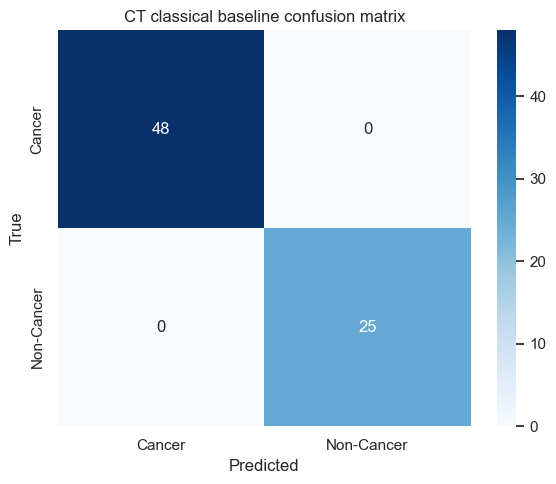

              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00        48
  Non-Cancer       1.00      1.00      1.00        25

    accuracy                           1.00        73
   macro avg       1.00      1.00      1.00        73
weighted avg       1.00      1.00      1.00        73



In [11]:
if len(df) > 0:
    best_pred = pred_rf if accuracy_score(y_test, pred_rf) >= accuracy_score(y_test, pred_logreg) else pred_logreg
    cm = confusion_matrix(y_test, best_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title("CT classical baseline confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))


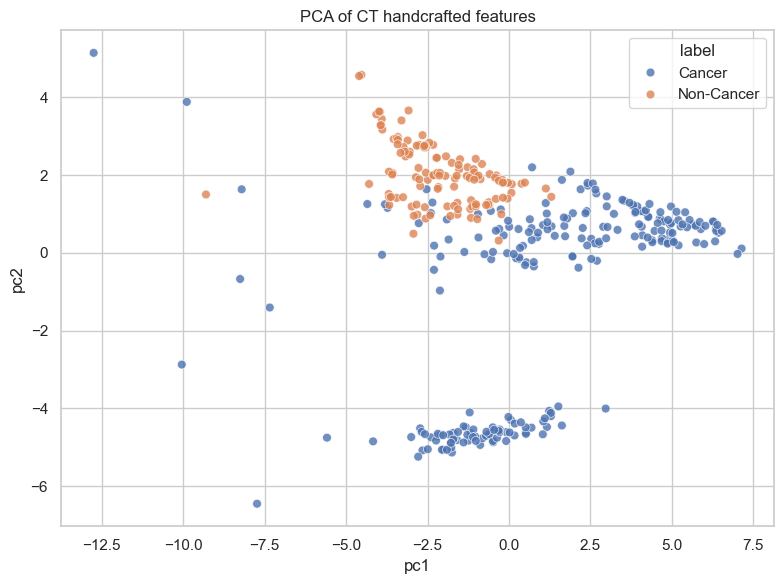

In [12]:
if len(df) > 0:
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X_hand))

    plot_df = pd.DataFrame({
        "pc1": X_pca[:, 0],
        "pc2": X_pca[:, 1],
        "label": df["label"].values
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="label", s=40, alpha=0.8)
    plt.title("PCA of CT handcrafted features")
    plt.tight_layout()
    plt.show()


## Small CNN baseline

Now I move to the deep baseline.

I keep the network small enough that I can explain every part of it clearly. I am not trying to win a benchmark. I am trying to build a readable and useful proof of concept.


In [13]:
train_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

class CTDataset(Dataset):
    def __init__(self, frame, label_encoder, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.label_encoder = label_encoder
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["path"]).convert("L")
        label = self.label_encoder.transform([row["label"]])[0]

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long), row["path"]

if len(df) > 0:
    train_dataset = CTDataset(df_train, label_encoder, transform=train_tfms)
    test_dataset = CTDataset(df_test, label_encoder, transform=test_tfms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)


In [14]:
class SmallCTCNN(nn.Module):
    def __init__(self, num_classes, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # I keep the embedding layer explicit because the embedding is part of the actual deliverable.
        self.embedding = nn.Linear(128, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        emb = self.embedding(x)
        logits = self.classifier(torch.relu(emb))

        if return_embedding:
            return logits, emb
        return logits

if len(df) > 0:
    model = SmallCTCNN(num_classes=len(label_encoder.classes_)).to(DEVICE)
    class_counts = df_train["label"].value_counts()
    counts = np.array([class_counts[label] for label in label_encoder.classes_], dtype=np.float32)

    # Higher weight for the rarer class
    weights = counts.sum() / counts
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

    print(model)


SmallCTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (embedding): Linear(in_features=128, out_features=128, bias=True)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


In [15]:
def train_one_epoch(model, loader, criterion, optimiser, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device).long()

        optimiser.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device).long()

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


In [16]:
history = []

if len(df) > 0:
    EPOCHS = 20

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, DEVICE)
        val_loss, val_acc, val_preds, val_labels = evaluate(model, test_loader, criterion, DEVICE)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(
            f"Epoch {epoch + 1:02d} | "
            f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
        )

    history_df = pd.DataFrame(history)
    display(history_df)


Epoch 01 | train loss 0.6938 | train acc 0.3471 | val loss 0.6894 | val acc 0.4932
Epoch 02 | train loss 0.6932 | train acc 0.5979 | val loss 0.6929 | val acc 0.6575
Epoch 03 | train loss 0.6932 | train acc 0.6529 | val loss 0.6922 | val acc 0.6575
Epoch 04 | train loss 0.6916 | train acc 0.6529 | val loss 0.6887 | val acc 0.6575
Epoch 05 | train loss 0.6838 | train acc 0.6632 | val loss 0.6634 | val acc 0.8082
Epoch 06 | train loss 0.6362 | train acc 0.6117 | val loss 0.7185 | val acc 0.6301
Epoch 07 | train loss 0.6787 | train acc 0.6289 | val loss 0.6273 | val acc 0.5753
Epoch 08 | train loss 0.6234 | train acc 0.5945 | val loss 0.5979 | val acc 0.7260
Epoch 09 | train loss 0.5791 | train acc 0.7320 | val loss 0.5335 | val acc 0.7123
Epoch 10 | train loss 0.5350 | train acc 0.6873 | val loss 0.6792 | val acc 0.5753
Epoch 11 | train loss 0.5368 | train acc 0.7182 | val loss 0.4931 | val acc 0.7260
Epoch 12 | train loss 0.4725 | train acc 0.7457 | val loss 0.3956 | val acc 0.8219
Epoc

,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.693793,0.347079,0.689351,0.493151
1,2,0.693228,0.597938,0.692890,0.657534
2,3,0.693183,0.652921,0.692218,0.657534
3,4,0.691631,0.652921,0.688742,0.657534
4,5,0.683817,0.663230,0.663427,0.808219
5,6,0.636249,0.611684,0.718489,0.630137
6,7,0.678715,0.628866,0.627304,0.575342
7,8,0.623373,0.594502,0.597949,0.726027
8,9,0.579127,0.731959,0.533547,0.712329
9,10,0.534955,0.687285,0.679222,0.575342


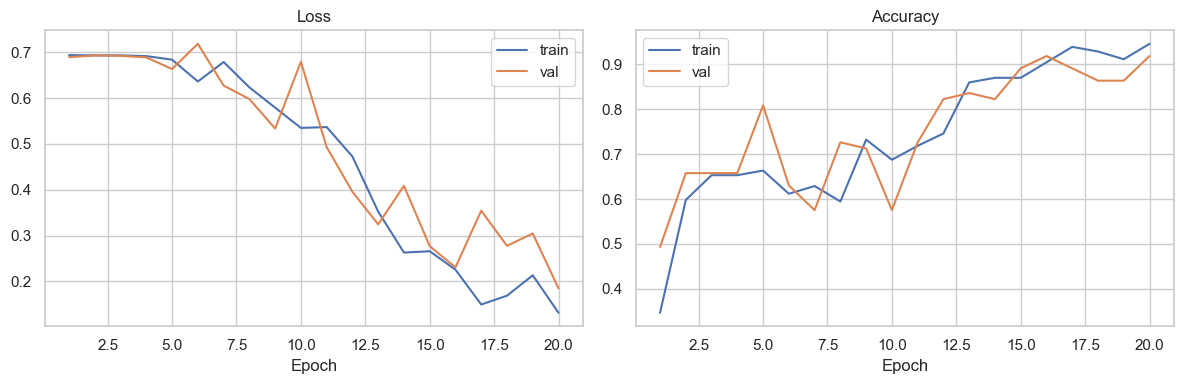

In [17]:
if len(df) > 0 and len(history) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


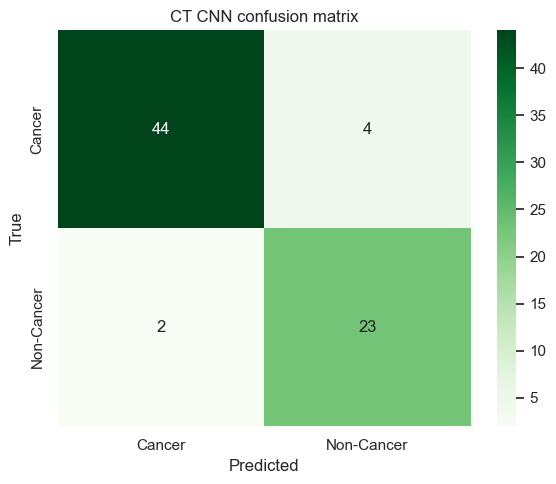

              precision    recall  f1-score   support

      Cancer       0.96      0.92      0.94        48
  Non-Cancer       0.85      0.92      0.88        25

    accuracy                           0.92        73
   macro avg       0.90      0.92      0.91        73
weighted avg       0.92      0.92      0.92        73



In [18]:
if len(df) > 0:
    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title("CT CNN confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print(classification_report(val_labels, val_preds, target_names=label_encoder.classes_))


## Export CT embeddings

This is the important part again.

I am not only building a classifier. I am building compact CT fingerprints that I can later compare, cluster, visualise, or use in downstream analysis.


In [19]:
@torch.no_grad()
def extract_embeddings(model, loader, device, label_encoder):
    model.eval()
    rows = []

    for images, labels, paths in tqdm(loader, desc="Extracting CT embeddings"):
        images = images.to(device)
        logits, emb = model(images, return_embedding=True)
        preds = logits.argmax(dim=1).cpu().numpy()
        emb = emb.cpu().numpy()
        labels = labels.numpy()

        for i in range(len(paths)):
            row = {
                "path": paths[i],
                "true_label": label_encoder.inverse_transform([labels[i]])[0],
                "pred_label": label_encoder.inverse_transform([preds[i]])[0],
            }
            for j, value in enumerate(emb[i]):
                row[f"emb_{j:03d}"] = float(value)
            rows.append(row)

    return pd.DataFrame(rows)

if len(df) > 0:
    full_dataset = CTDataset(df, label_encoder, transform=test_tfms)
    full_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=0)

    embeddings_df = extract_embeddings(model, full_loader, DEVICE, label_encoder)
    embeddings_path = OUTPUT_DIR / "ct_slice_embeddings.csv"
    embeddings_df.to_csv(embeddings_path, index=False)

    print("Saved embeddings to:", embeddings_path.resolve())
    display(embeddings_df.head())


Extracting CT embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Saved embeddings to: C:\Users\nosai\Downloads\CT_first_poc_repo\data\ct-scan Images\outputs\ct_slice_embeddings.csv


,path,true_label,pred_label,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer,Cancer,-0.490925,0.120662,-0.897660,-0.407498,0.917073,0.775728,-0.231039,...,0.823955,0.388812,0.629171,0.745965,0.560187,0.629148,-0.494499,-0.580102,-0.024048,1.092324
1,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer,Cancer,-0.531354,0.185884,-0.885951,-0.322403,0.516330,0.419793,-0.233086,...,0.457361,0.219555,0.778398,1.108289,0.332306,0.321100,-0.491763,-0.635683,0.077903,0.610966
2,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer,Cancer,-0.420435,0.052213,-0.851088,-0.444502,1.257219,1.082706,-0.226559,...,1.138494,0.517820,0.420903,0.337284,0.744968,0.910110,-0.487693,-0.487418,-0.111764,1.513979
3,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer,Cancer,-0.386329,0.003220,-0.854631,-0.502140,1.532677,1.323053,-0.221994,...,1.382454,0.632879,0.305571,0.075209,0.905920,1.113758,-0.482253,-0.445323,-0.185434,1.841185
4,C:\Users\nosai\Downloads\CT_first_poc_repo\dat...,Cancer,Cancer,-0.416244,0.065207,-0.814249,-0.402756,1.108849,0.958081,-0.224543,...,1.015525,0.452980,0.438129,0.413840,0.655920,0.808998,-0.478362,-0.482887,-0.083549,1.344053


In [20]:
if len(df) > 0:
    model_path = OUTPUT_DIR / "small_ct_cnn.pt"
    torch.save(model.state_dict(), model_path)
    print("Saved model weights to:", model_path.resolve())


Saved model weights to: C:\Users\nosai\Downloads\CT_first_poc_repo\data\ct-scan Images\outputs\small_ct_cnn.pt


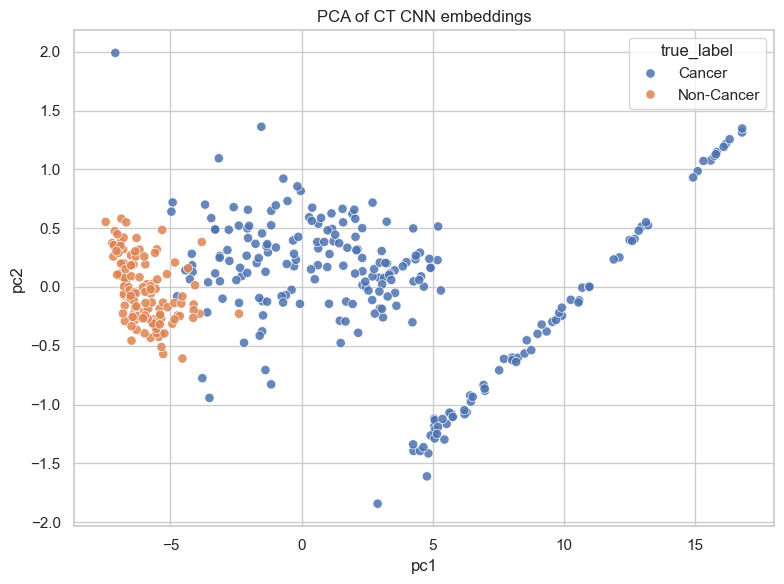

In [21]:
if len(df) > 0:
    emb_cols = [c for c in embeddings_df.columns if c.startswith("emb_")]
    pca_emb = PCA(n_components=2, random_state=SEED)
    emb_2d = pca_emb.fit_transform(embeddings_df[emb_cols].values)

    plot_emb = embeddings_df[["true_label"]].copy()
    plot_emb["pc1"] = emb_2d[:, 0]
    plot_emb["pc2"] = emb_2d[:, 1]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_emb, x="pc1", y="pc2", hue="true_label", s=45, alpha=0.85)
    plt.title("PCA of CT CNN embeddings")
    plt.tight_layout()
    plt.show()


## What I am trying to get from this notebook

I am trying to get three things from this workflow:

- a CT baseline I can explain properly
- a small CNN I can compare against that baseline
- exportable embeddings that make the pipeline useful beyond plain classification

If I get those three, this notebook has done its job.
